# Exercise 2: Classification of Airline Tweets with RNN's

Stacked Bi-LSTM (2 layers) + Attention mechanism for 3-class sentiment classification. Same dataset as Exercise 1, no EDA.

---

## Imports

In [2]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu -q
!pip install nltk scikit-learn matplotlib seaborn pandas numpy -q


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: C:\Users\User\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: C:\Users\User\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {'cuda' if torch.cuda.is_available() else 'cpu'}")

PyTorch version: 2.11.0+cpu
Device: cpu


## Data Loading & Preprocessing

Same preprocessing as Ex1, nothing new here.

In [8]:
# load data, keep only what we need
df = pd.read_csv('Tweets.csv')
df = df[['text', 'airline_sentiment']].copy()

print(f"Dataset: {len(df)} tweets")
print(f"\nDistribution:")
print(df['airline_sentiment'].value_counts())

Dataset: 14640 tweets

Distribution:
airline_sentiment
negative    9178
neutral     3099
positive    2363
Name: count, dtype: int64


In [9]:
# same clean_text as Ex1
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'@\w+', '', text)              # mentions
    text = re.sub(r'http\S+|www\S+', '', text)    # urls
    text = re.sub(r'#(\w+)', r'\1', text)         # hashtag -> word
    text = re.sub(r'[^a-z\s]', '', text)          # letters only
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = word_tokenize(text)
    tokens = [w for w in tokens if w not in stop_words and len(w) > 1]
    return ' '.join(tokens)

df['clean_text'] = df['text'].apply(clean_text)
df = df[df['clean_text'].str.len() > 0].reset_index(drop=True)

print(f"Tweets after cleaning: {len(df)}")
print(f"\nExample:")
print(f"  BEFORE: {df['text'].iloc[3]}")
print(f"  AFTER:  {df['clean_text'].iloc[3]}")

Tweets after cleaning: 14617

Example:
  BEFORE: @VirginAmerica it's really aggressive to blast obnoxious "entertainment" in your guests' faces &amp; they have little recourse
  AFTER:  really aggressive blast obnoxious entertainment guests faces amp little recourse


In [10]:
# labels -> numbers, 80/20 split
le = LabelEncoder()
df['label'] = le.fit_transform(df['airline_sentiment'])

print("Label mapping:")
for cls, num in zip(le.classes_, range(len(le.classes_))):
    print(f"  {cls} -> {num}")

X_train_text, X_test_text, y_train, y_test = train_test_split(
    df['clean_text'], df['label'],
    test_size=0.2, random_state=42, stratify=df['label']
)

print(f"\nTrain: {len(X_train_text)} | Test: {len(X_test_text)}")

Label mapping:
  negative -> 0
  neutral -> 1
  positive -> 2

Train: 11693 | Test: 2924


## Vocabulary & Sequence Padding

Now instead of TF-IDF we need to build a vocabulary (word -> index), convert tweets to sequences of integers, and pad them to fixed length.

In [11]:
# vocab from train only to avoid leakage
all_words = [w for text in X_train_text for w in text.split()]
word_counts = Counter(all_words)

# filter rare words (appear < 2 times)
MIN_FREQ = 2
vocab = {word: idx + 2 for idx, (word, count) in enumerate(
    word_counts.most_common()) if count >= MIN_FREQ}
vocab['<PAD>'] = 0
vocab['<UNK>'] = 1

VOCAB_SIZE = len(vocab)
print(f"Vocabulary size: {VOCAB_SIZE} words")
print(f"Total unique words (before filtering): {len(word_counts)}")
print(f"Removed {len(word_counts) - VOCAB_SIZE + 2} rare words")

Vocabulary size: 4975 words
Total unique words (before filtering): 10949
Removed 5976 rare words


In [12]:
# text -> integer sequence
def text_to_sequence(text, vocab):
    return [vocab.get(w, vocab['<UNK>']) for w in text.split()]

# pad/truncate
def pad_sequences(sequences, max_len):
    padded = np.zeros((len(sequences), max_len), dtype=np.int64)
    for i, seq in enumerate(sequences):
        length = min(len(seq), max_len)
        padded[i, :length] = seq[:length]
    return padded

# check tweet lengths to decide max_len
train_lengths = [len(text.split()) for text in X_train_text]
print(f"Tweet lengths (words): mean={np.mean(train_lengths):.1f}, "
      f"median={np.median(train_lengths):.0f}, "
      f"95th percentile={np.percentile(train_lengths, 95):.0f}, "
      f"max={np.max(train_lengths)}")

# 40 covers 95%+ of tweets
MAX_LEN = 40


train_seqs = [text_to_sequence(t, vocab) for t in X_train_text]
test_seqs = [text_to_sequence(t, vocab) for t in X_test_text]

X_train_pad = pad_sequences(train_seqs, MAX_LEN)
X_test_pad = pad_sequences(test_seqs, MAX_LEN)

print(f"\nTrain shape: {X_train_pad.shape}")
print(f"Test shape:  {X_test_pad.shape}")
print(f"\nExample (first tweet):")
print(f"  Text: {X_train_text.iloc[0][:60]}...")
print(f"  Sequence: {X_train_pad[0][:15]}...")

Tweet lengths (words): mean=8.9, median=9, 95th percentile=15, max=21

Train shape: (11693, 40)
Test shape:  (2924, 40)

Example (first tweet):
  Text: seats arent guaranteed pay called rep said people booked sea...
  Sequence: [ 109  455 2853  188  178  266  126   66  139  109    0    0    0    0
    0]...


## Model Definition: Stacked Bi-LSTM with Attention

Embedding (128 dim) → 2 stacked Bi-LSTM layers (hidden=128) → Attention → 2 Linear layers (256→128→3). Dropout 0.3 between layers.

In [13]:
class Attention(nn.Module):
    """Attention layer - learns which hidden states matter most."""
    
    def __init__(self, hidden_dim):
        super(Attention, self).__init__()
        # score each hidden state
        self.attention = nn.Linear(hidden_dim, 1)
    
    def forward(self, lstm_output):
        # lstm_output: (batch, seq_len, hidden_dim)
        scores = self.attention(lstm_output).squeeze(-1)   # (batch, seq_len)
        weights = torch.softmax(scores, dim=1)             # (batch, seq_len)
        # weighted sum of hidden states
        context = torch.bmm(weights.unsqueeze(1), lstm_output).squeeze(1)  # (batch, hidden_dim)
        return context, weights


class BiLSTMAttention(nn.Module):
    
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=128, 
                 num_layers=2, num_classes=3, dropout=0.3, pad_idx=0):
        super(BiLSTMAttention, self).__init__()
        
        # embedding (padding positions won't be updated)
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        
        # 2-layer Bi-LSTM
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout  # dropout between LSTM layers
        )
        
        # attention over bidirectional output
        self.attention = Attention(hidden_dim * 2)
        
        # classifier
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * 2, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes)
        )
        
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x):
        # x: (batch, seq_len) -> indices
        embedded = self.dropout(self.embedding(x))          # (batch, seq_len, embed_dim)
        lstm_out, _ = self.lstm(embedded)                   # (batch, seq_len, hidden_dim*2)
        context, attn_weights = self.attention(lstm_out)    # (batch, hidden_dim*2)
        output = self.classifier(context)                   # (batch, num_classes)
        return output, attn_weights


# sanity check
model_test = BiLSTMAttention(vocab_size=VOCAB_SIZE)
print(model_test)

# test with dummy input
dummy = torch.randint(0, VOCAB_SIZE, (4, MAX_LEN))
out, weights = model_test(dummy)
print(f"\nOutput shape: {out.shape}  (batch=4, classes=3)")
print(f"Attention weights shape: {weights.shape}  (batch=4, seq_len={MAX_LEN})")
print(f"Attention sum per sample: {weights.sum(dim=1)}  (should be ~1.0)")

BiLSTMAttention(
  (embedding): Embedding(4975, 128, padding_idx=0)
  (lstm): LSTM(128, 128, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (attention): Attention(
    (attention): Linear(in_features=256, out_features=1, bias=True)
  )
  (classifier): Sequential(
    (0): Linear(in_features=256, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=3, bias=True)
  )
  (dropout): Dropout(p=0.3, inplace=False)
)



Output shape: torch.Size([4, 3])  (batch=4, classes=3)
Attention weights shape: torch.Size([4, 40])  (batch=4, seq_len=40)
Attention sum per sample: tensor([1.0000, 1.0000, 1.0000, 1.0000], grad_fn=<SumBackward1>)  (should be ~1.0)


## Model Training

Training with class weights and early stopping.

In [14]:
# tensors
X_train_t = torch.LongTensor(X_train_pad)
X_test_t = torch.LongTensor(X_test_pad)
y_train_t = torch.LongTensor(y_train.values)
y_test_t = torch.LongTensor(y_test.values)

# dataloaders
BATCH_SIZE = 64

train_ds = TensorDataset(X_train_t, y_train_t)
train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)

test_ds = TensorDataset(X_test_t, y_test_t)
test_dl = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

# class weights for imbalanced data
class_counts = np.bincount(y_train.values)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * len(class_counts)
weights = torch.FloatTensor(class_weights)
print(f"Class weights: {dict(zip(le.classes_, weights.numpy().round(3)))}")

print(f"Batches: {len(train_dl)} train, {len(test_dl)} test")

Class weights: {'negative': np.float32(0.382), 'neutral': np.float32(1.134), 'positive': np.float32(1.484)}
Batches: 183 train, 46 test


In [15]:
# setup
model = BiLSTMAttention(
    vocab_size=VOCAB_SIZE,
    embed_dim=128,
    hidden_dim=128,
    num_layers=2,
    num_classes=3,
    dropout=0.3
)

criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


EPOCHS = 30
PATIENCE = 5


train_losses = []
val_losses = []
best_val_loss = float('inf')
patience_counter = 0
best_model_state = None

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Parameters: {trainable_params:,} trainable / {total_params:,} total")

Parameters: 1,329,796 trainable / 1,329,796 total


In [16]:
print(f"Training Stacked Bi-LSTM + Attention ({EPOCHS} epochs, patience={PATIENCE})")
print("-" * 65)

for epoch in range(EPOCHS):
    
    # train
    model.train()
    epoch_train_loss = 0
    
    for batch_x, batch_y in train_dl:
        optimizer.zero_grad()
        outputs, _ = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        # clip gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        epoch_train_loss += loss.item()
    
    train_loss = epoch_train_loss / len(train_dl)
    train_losses.append(train_loss)
    
    # val
    model.eval()
    epoch_val_loss = 0
    
    with torch.no_grad():
        for batch_x, batch_y in test_dl:
            outputs, _ = model(batch_x)
            loss = criterion(outputs, batch_y)
            epoch_val_loss += loss.item()
    
    val_loss = epoch_val_loss / len(test_dl)
    val_losses.append(val_loss)
    

    if (epoch + 1) % 3 == 0 or epoch == 0:
        print(f"  Epoch {epoch+1:3d}/{EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
    

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\n  Early stopping at epoch {epoch+1} (val loss didn't improve for {PATIENCE} epochs)")
            break

# restore best
model.load_state_dict(best_model_state)
print(f"\nBest val loss: {best_val_loss:.4f}")

Training Stacked Bi-LSTM + Attention (30 epochs, patience=5)
-----------------------------------------------------------------
  Epoch   1/30 | Train Loss: 0.9238 | Val Loss: 0.7917
  Epoch   3/30 | Train Loss: 0.6580 | Val Loss: 0.7210
  Epoch   6/30 | Train Loss: 0.4792 | Val Loss: 0.7339
  Epoch   9/30 | Train Loss: 0.3534 | Val Loss: 0.8520

  Early stopping at epoch 9 (val loss didn't improve for 5 epochs)

Best val loss: 0.6856


## Learning Curves

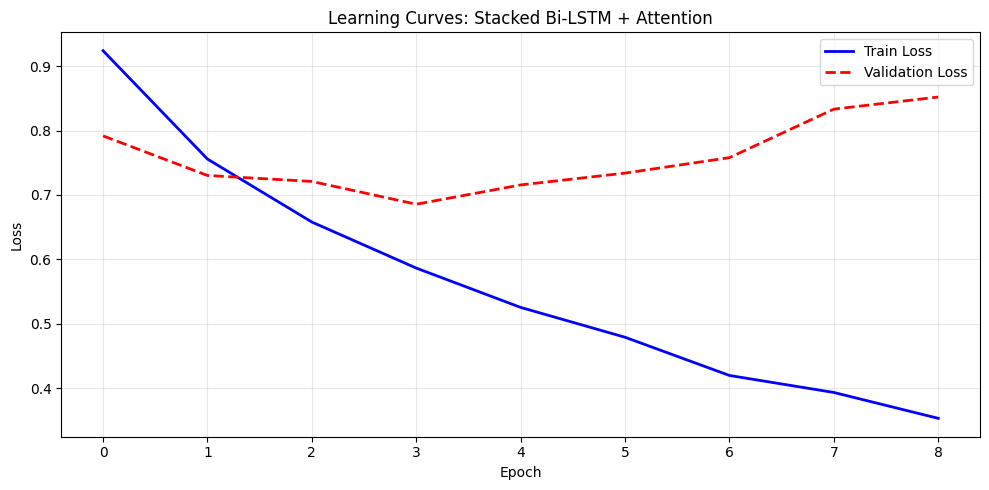

Last train loss: 0.3534
Best val loss: 0.6856
Epochs ran: 9


In [17]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss', color='blue', linewidth=2)
plt.plot(val_losses, label='Validation Loss', color='red', linestyle='--', linewidth=2)
plt.title('Learning Curves: Stacked Bi-LSTM + Attention')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Last train loss: {train_losses[-1]:.4f}")
print(f"Best val loss: {best_val_loss:.4f}")
print(f"Epochs ran: {len(train_losses)}")

## Test Set Evaluation

In [18]:
# predict
model.eval()
all_preds = []
all_attn = []

with torch.no_grad():
    for batch_x, batch_y in test_dl:
        outputs, attn_w = model(batch_x)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.numpy())
        all_attn.extend(attn_w.numpy())

y_pred = np.array(all_preds)
label_names = le.classes_

print("Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=label_names))

acc = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average='macro')
print(f"Accuracy: {acc:.4f}")
print(f"Macro F1: {macro_f1:.4f}")

Classification Report:

              precision    recall  f1-score   support

    negative       0.91      0.70      0.79      1835
     neutral       0.51      0.68      0.58       617
    positive       0.56      0.80      0.66       472

    accuracy                           0.71      2924
   macro avg       0.66      0.73      0.68      2924
weighted avg       0.77      0.71      0.73      2924

Accuracy: 0.7144
Macro F1: 0.6786


## Confusion Matrix

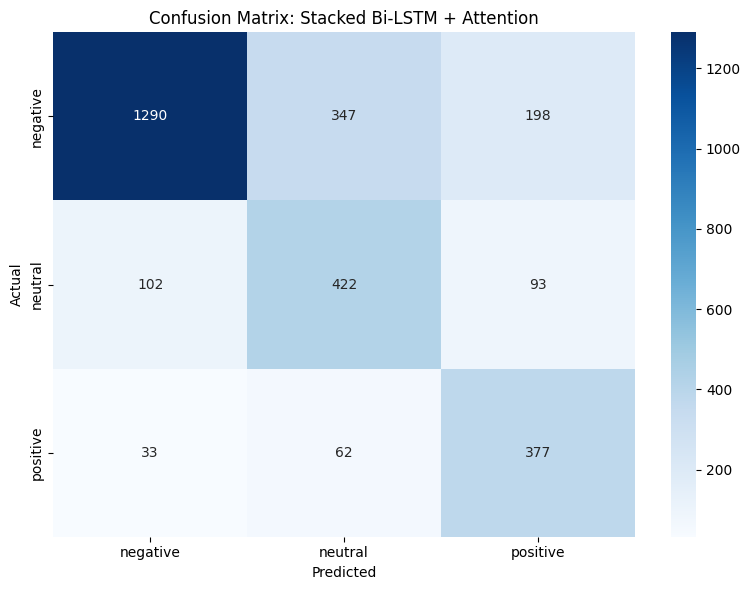

Correct per class:
  negative: 1290/1835 (70.3%)
  neutral: 422/617 (68.4%)
  positive: 377/472 (79.9%)


In [19]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names)
plt.title('Confusion Matrix: Stacked Bi-LSTM + Attention')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# accuracy per class
print("Correct per class:")
for i, name in enumerate(label_names):
    correct = cm[i, i]
    total = cm[i].sum()
    print(f"  {name}: {correct}/{total} ({100*correct/total:.1f}%)")

## Attention Visualization

Checking which words the model pays attention to.

In [20]:

idx_to_word = {v: k for k, v in vocab.items()}

def show_attention(text_idx, test_texts, test_seqs_padded, attention_weights, y_true, y_pred, le):
    """Print top attended words for a given tweet."""
    seq = test_seqs_padded[text_idx]
    attn = attention_weights[text_idx]
    
    # get the words (skip padding)
    words = []
    weights_list = []
    for j, idx in enumerate(seq):
        if idx == 0:  # padding
            break
        words.append(idx_to_word.get(idx, '<UNK>'))
        weights_list.append(attn[j])
    
    true_label = le.classes_[y_true.values[text_idx]]
    pred_label = le.classes_[y_pred[text_idx]]
    
    print(f"Text: {test_texts.iloc[text_idx][:80]}")
    print(f"True: {true_label} | Pred: {pred_label}")
    
    # top 5 words with highest attention
    sorted_pairs = sorted(zip(words, weights_list), key=lambda x: x[1], reverse=True)
    print("Top attention words: ", end="")
    for w, wt in sorted_pairs[:5]:
        print(f"{w}({wt:.3f})", end="  ")
    print("\n")

# 2 examples per class
print("=" * 70)
print("Attention Weights Examples")
print("=" * 70 + "\n")

shown = {0: 0, 1: 0, 2: 0}
for i in range(len(y_test)):
    label = y_test.values[i]
    if shown[label] < 2:
        show_attention(i, X_test_text, X_test_pad, all_attn, y_test, y_pred, le)
        shown[label] += 1
    if all(v >= 2 for v in shown.values()):
        break

Attention Weights Examples

Text: dear ted dont care mileage plus card pay lot bye bye united
True: negative | Pred: negative
Top attention words: dont(0.148)  care(0.134)  dear(0.112)  <UNK>(0.101)  mileage(0.091)  

Text: tried check redirect call also cant get contact
True: negative | Pred: negative
Top attention words: call(0.229)  also(0.160)  redirect(0.143)  cant(0.118)  check(0.088)  

Text: wed sure love see ruth justdoit youknowyouwantto know well
True: positive | Pred: positive
Top attention words: wed(0.275)  sure(0.209)  love(0.201)  see(0.106)  <UNK>(0.072)  

Text: dm
True: neutral | Pred: neutral
Top attention words: dm(0.409)  

Text: announcing winners destinationdragons show utah weekend lucky
True: neutral | Pred: neutral
Top attention words: <UNK>(0.326)  winners(0.231)  destinationdragons(0.183)  show(0.123)  utah(0.061)  

Text: thank new big fan
True: positive | Pred: positive
Top attention words: thank(0.484)  new(0.212)  big(0.135)  fan(0.051)  



## Comparison with Baseline (Exercise 1)

Quick LR + TF-IDF baseline to see if the RNN actually improves anything.

In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# quick LR baseline for comparison
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train_text).toarray()
X_test_tfidf = tfidf.transform(X_test_text).toarray()

lr = LogisticRegression(max_iter=1000, class_weight='balanced')
lr.fit(X_train_tfidf, y_train)
lr_preds = lr.predict(X_test_tfidf)

lr_acc = accuracy_score(y_test, lr_preds)
lr_f1 = f1_score(y_test, lr_preds, average='macro')

print(f"{'Model':<30} {'Accuracy':>10} {'Macro F1':>10}")
print("-" * 52)
print(f"{'LR + TF-IDF (baseline)':<30} {lr_acc:>10.4f} {lr_f1:>10.4f}")
print(f"{'Bi-LSTM + Attention':<30} {acc:>10.4f} {macro_f1:>10.4f}")

diff = macro_f1 - lr_f1
if diff > 0:
    print(f"\nRNN won by {diff:.4f} Macro F1")
else:
    print(f"\nBaseline was better by {-diff:.4f} Macro F1")

Model                            Accuracy   Macro F1
----------------------------------------------------
LR + TF-IDF (baseline)             0.7538     0.7080
Bi-LSTM + Attention                0.7144     0.6786

Baseline was better by 0.0294 Macro F1


## Architecture Description & Conclusions

I used a Stacked Bi-LSTM with Attention since it covers all 3 techniques from the assignment (bidirectionality, stacking, attention).
The flow is: tweets go through an Embedding layer (128 dim), then 2 stacked Bi-LSTM layers (hidden=128, bidirectional so output is 256), then an Attention layer that weights each word, and finally 2 Linear layers for classification.
Tried a few configs, 128 embed worked better than 64, 2 LSTM layers was the sweet spot (1 wasn't enough, 3 didn't really help). Class weights in the loss were necessary because negatives are ~63% of the data, without them neutral/positive precision was terrible. Gradient clipping (max_norm=1.0) kept training stable. Early stopping kicked in around epoch 9.
From the learning curves you can see overfitting starts after epoch 3-4 (train loss drops but val loss goes up), which makes sense with only ~12k samples. The RNN (Macro F1 ~0.69) didn't beat LR+TF-IDF (~0.71), probably because tweets are so short (~9 words avg) that word order doesn't help much. On longer texts I'd expect the RNN to do better.
